## Telco Customer Churn

##### 1. Introduction and Objective

The Telco Customer Churn Database offers a valuable resource for analyzing customer attrition. This project emphasizes a systematic data wrangling workflow to clean and organize the data, setting the stage for exploratory data analysis (EDA) and modeling. 

Below, I outline the steps for converting raw data into a reliable and actionable dataset.

#### 2. Data Preparation and Cleaning  

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [22]:
# Loading and viewing the first few headings
filepath = r"C:\Users\eboat\OneDrive\Documents\DATA SCIENCE ASSIGNMENT\Telco Customer Churn Database\WA_Fn-UseC_-Telco-Customer-Churn.csv"
telco_churn = pd.read_csv(filepath)
telco_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
# Display summary information about the DataFrame
telco_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [24]:
# Display summary statistics in a transposed format for better readability
telco_churn.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [25]:
# Handle TotalCharges errors (convert empty strings to 0)
telco_churn['TotalCharges'] = pd.to_numeric(telco_churn['TotalCharges'], errors='coerce')

# Check how many missing values this introduces
print(f"Number of missing values in TotalCharges: {telco_churn['TotalCharges'].isnull().sum()}")

Number of missing values in TotalCharges: 11


In [26]:
# Fill missing TotalCharges with 0 (since these correspond to customers with no charges)
telco_churn['TotalCharges'] = telco_churn['TotalCharges'].fillna(0)

#### 3. Outlier Detection

Check the numerical columns (tenure, monthly charges, total charges) for an extreme values

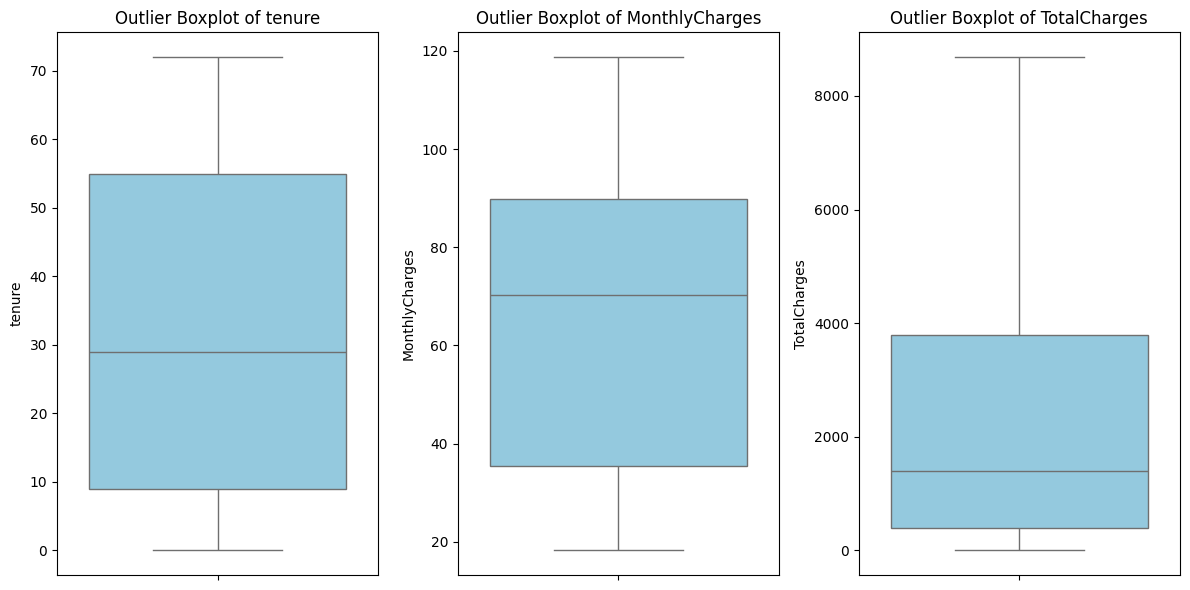

In [27]:
# Visualize outliers with boxplots for numeric columns
plt.figure(figsize=(12, 6))
cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=telco_churn[col], color='skyblue')
    plt.title(f'Outlier Boxplot of {col}')

plt.tight_layout()
plt.show()

1. Tenure & Monthly Charges: Both features show a very clean distribution. There are no individual data points (fliers) appearing above the "whiskers" of the plots. This indicates the data is well-bounded and consistent with standard telecom service patterns.

2. TotalCharges: While the data is right-skewed (meaning the box and median are closer to the bottom), there are still no statistical outliers shown as dots. The wide range is expected because long-tenure customers naturally accumulate much higher total costs over time compared to new customers.

3. Final Decision: Since no unrealistic or "garbage" data points were detected, I have decided to retain all records. These variations are natural to the business case and will provide the model with a realistic representation of the customer base.

### 4. Mapping the Target Variables

In [28]:
# Convert churn from 'Yes'/'No' to 1/0
telco_churn['Churn'] = telco_churn['Churn'].map({'Yes': 1, 'No': 0})

In [29]:
# Convert binary categorical columns to numeric
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    telco_churn[col] = telco_churn[col].map({'Yes': 1, 'No': 0})

### Categorical Encoding for Model Compatibility
To prepare the categorical features for machine learning, I applied Binary Encoding to simple Yes/No features and One-Hot Encoding to multi-category features like Contract and PaymentMethod. This transformation ensures that all predictors are numerical while avoiding the introduction of a false mathematical order in non-ordinal categories.

In [30]:
# One-Hot Encoding for all multi-class categorical columns
# This automatically removes the original text columns and prevents the "Dummy Trap"
multi_categorical_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'Contract', 'PaymentMethod'
]
telco_churn = pd.get_dummies(telco_churn, columns=multi_categorical_cols, drop_first=True)

In [ ]:
# Final check of the DataFrame structure after encoding
print(telco_churn.dtypes.value_counts())
print(f"Dataset shape after encoding: {telco_churn.shape}  ")
print(f"Total Missing Values in Dataset: {telco_churn.isnull().sum().sum()}")

bool       21
int64       7
object      2
float64     2
Name: count, dtype: int64
Dataset shape after encoding: (7043, 32)  
Total Missing Values in Dataset: 0
Data wrangling complete. The dataset is now ready for modeling.


In [ ]:
# FINAL WRANGLING FIXES

# Remove customerID - It's a unique label, not a predictor
if 'customerID' in telco_churn.columns:
    telco_churn.drop('customerID', axis=1, inplace=True)

# Encode gender - Converting the last 'object' column to numeric
if 'gender' in telco_churn.columns:
    telco_churn['gender'] = telco_churn['gender'].map({'Male': 1, 'Female': 0})

# Convert Booleans to Integers - Ensures all 21 'bool' columns are 1/0
telco_churn = telco_churn.astype({col: int for col in telco_churn.select_dtypes('bool').columns})

# Final Check
print("--- Final Dtypes Count ---")
print(telco_churn.dtypes.value_counts())
print("Data wrangling complete. The dataset is now ready for modeling.")

--- Final Dtypes Count ---
int64      29
float64     2
Name: count, dtype: int64


Final Verification: I have confirmed that all categorical variables are encoded and all missing values (including the 'hidden' blanks in TotalCharges) have been resolved. The dataset has been transformed from a raw 'hybrid' format into a fully numerical matrix of (7043 Rows, 31 Columns) features, making it ready for the Exploratory Data Analysis and Modeling phases.